In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [4]:
data = pd.read_csv("encoded_car_data (1).csv")
print(data.head())

   diesel  gas  std  turbo  convertible  hardtop  hatchback  sedan  wagon  \
0     0.0  1.0  1.0    0.0          1.0      0.0        0.0    0.0    0.0   
1     0.0  1.0  1.0    0.0          1.0      0.0        0.0    0.0    0.0   
2     0.0  1.0  1.0    0.0          0.0      0.0        1.0    0.0    0.0   
3     0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   
4     0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   

   4wd  ...  wheelbase  curbweight  enginesize  boreratio  horsepower  \
0  0.0  ...       88.6      2548.0       130.0       3.47       111.0   
1  0.0  ...       88.6      2548.0       130.0       3.47       111.0   
2  0.0  ...       94.5      2823.0       152.0       2.68       154.0   
3  0.0  ...       99.8      2337.0       109.0       3.19       102.0   
4  1.0  ...       99.4      2824.0       136.0       3.19       115.0   

   carlength  carwidth  citympg  highwaympg    price  
0      168.8      64.1     21.0        27.0

In [5]:
data = pd.get_dummies (data, drop_first=True)

In [20]:
x=data.drop('price', axis=1)
y= data['price']

In [22]:
scaler = StandardScaler()
x = scaler.fit_transform (x)
У = scaler.fit_transform(y.values.reshape(-1, 1))

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
models = {
"Ridge": Ridge(alpha=1.0),
"Lasso": Lasso (alpha=1.0),
"ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

In [28]:
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('poly', PolynomialFeatures (degree=2)),
        ('regressor', model)
    ])


In [29]:
pipeline.fit(x_train, y_train)
predictions = pipeline.predict(x_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [33]:
results [name] ={'MSE': mse, 'R2_Score': r2}

In [34]:
print('Name:S R NIVEDHITHA')
print('Reg. No:212225240102')
for model_name, metrics in results.items():
    print(f"{model_name} - Mean Squared Error: {metrics ['MSE']:.2f}, R2_Score: {metrics['R2_Score']:.2f}")

Name:S R NIVEDHITHA
Reg. No:212225240102
ElasticNet - Mean Squared Error: 15266807.84, R2_Score: 0.81


In [35]:
results_df = pd.DataFrame (results).T
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)


In [36]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

(array([0]), [Text(0, 0, 'ElasticNet')])

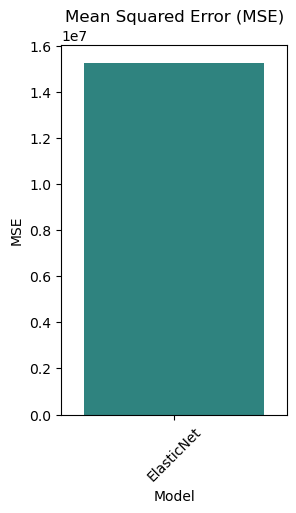

In [37]:
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xticks (rotation=45)

(array([0]), [Text(0, 0, 'ElasticNet')])

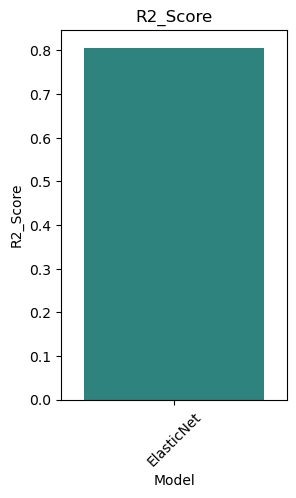

In [40]:
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R2_Score', data=results_df, palette='viridis')
plt.title('R2_Score')
plt.ylabel('R2_Score')
plt.xticks (rotation=45)

In [ ]:
plt.tight_layout()
plt.show()